In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [345]:
class WindowDataset(Dataset):
    # 단변량 시계열 데이터에서 입력 값, 정받ㅂ 값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태가 1차원 tensor 데이터
        # _window : 과거의 몇개의 데이터를 볼 것인가? (구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수는 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window
    
    # __len__(), __getitem__() 두개의 특수 합수들은 DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __len__(self):
        return max(self.n, 0)
    
    def __getitem__(self, idx):
        # 변환
        # x -> 입력 데이터 (윈도우의 구간을 나타내는 구간) --> 문제
        # y -> 입력 데이터 다음 행의 데이터 --> 정답
        x = self.data[idx : idx+self.window].unsqueeze(-1)  # (window,) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x, y

In [346]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, foward()함수
    
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size= input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        #self.head = nn.Linear(hidden_size, 1)      # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size을 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Linear(out_features, out_features * 2),
            nn.ReLU(),
            nn.Linear(out_features * 2, 1)
            
        )
        
    def forward(self, x):
        # out -> 모든 시점에서는 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값
        # -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

### 문제
- csv 폴더 안에 있는 AAPL.csv 파일을 로드
- 해당 데이터프레임에서 Date, Adj Close 컬럼을 제외한 나머지는 모두 삭제
- 결측치가 포함되어있는지 확인하고 결측치 데이터가 전체 데이터 수의 비해 매우 작은 크기라면 제거
- 해당 데이터셋의 순서가 시간의 순서와 같은지 확인 (시간 컬럼을 기준으로 오름차순 정렬)
- tensor 데이터를 생성하기 위해 Adj Close의 데이터 array 형태((N, 1))로 변경
- train, test의 비율이 75:25의 비율로 데이터를 나눠준다.
- train과 test를 스케일러를 이용하여 스케일링
- train과 test를 Tensor의 형태로 변환
- tensor형태로 변환된 데이터를 Windowdataset의 형태로 변경하고 DataLoader를 이용하여 학습에서 사용하기 편한 형태로 변경 (window의 개수는 60)

In [347]:
df = pd.read_csv("../csv/AAPL.csv")
df.head(0)

,Date,Open,High,Low,Close,Adj Close,Volume


In [348]:
df = df[['Date','Adj Close']]

In [349]:
df.isna().sum()

Date         0
Adj Close    1
dtype: int64

In [350]:
df = df.dropna()

In [351]:
df.sort_values('Date', inplace=True)

In [352]:
# df[['Adj Close']].values
data = df['Adj Close'].values.reshape(-1, 1)

In [353]:
split_idx = int(len(data) * 0.75)
train_data = data[: split_idx]
test_data = data[split_idx :] 

In [354]:
scaler = MinMaxScaler()
train_data_sc = scaler.fit_transform(train_data)
test_data_sc = scaler.transform(test_data)

In [355]:
train_data = torch.tensor(train_data_sc.squeeze(-1), dtype=torch.float32)
test_data = torch.tensor(test_data_sc.squeeze(-1), dtype=torch.float32)

In [359]:
window = 60
train_ds = WindowDataset(train_data, window)
test_ds = WindowDataset(test_data, window)
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=128)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)   

In [360]:
rnn_model = RNNReg(
    input_size=1, hidden_size=128#, nonlinearity='relu'
)

# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
# 함수 호출 시 동시에 실행이 되는 데코레이터 생성
@torch.no_grad()
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    # with torch.no_grad():
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        # 총 손실
        total_loss += loss.item() * y.size(0)
        # loss.itme() : 손실의 평균
        # size(0) : 개수
        total_n += y.size(0)
    return total_loss / max(total_n, 1)


In [361]:
for epoch in range(20):
    rnn_model.train()
    running=0.0
    n_seen = 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        
        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        running += loss.item() * y.size(0)
        n_seen += y.size(0)
        
    train_mse = running / max(n_seen, 1)
    test_mse = evaliate_mse(test_dl)
    print(f"epoch : {epoch + 1}, train_mse : {round(train_mse, 3)}, test_mse : {round(test_mse, 5)}")

epoch : 1, train_mse : 0.008, test_mse : 4.29337
epoch : 2, train_mse : 0.0, test_mse : 3.96707
epoch : 3, train_mse : 0.0, test_mse : 3.7609
epoch : 4, train_mse : 0.0, test_mse : 3.70174
epoch : 5, train_mse : 0.0, test_mse : 3.5227
epoch : 6, train_mse : 0.0, test_mse : 3.30848
epoch : 7, train_mse : 0.0, test_mse : 3.16722
epoch : 8, train_mse : 0.0, test_mse : 2.93773
epoch : 9, train_mse : 0.0, test_mse : 2.85321
epoch : 10, train_mse : 0.0, test_mse : 2.83107
epoch : 11, train_mse : 0.0, test_mse : 2.71428
epoch : 12, train_mse : 0.0, test_mse : 2.55231
epoch : 13, train_mse : 0.0, test_mse : 2.49239
epoch : 14, train_mse : 0.0, test_mse : 2.40173
epoch : 15, train_mse : 0.0, test_mse : 2.28068
epoch : 16, train_mse : 0.0, test_mse : 2.20672
epoch : 17, train_mse : 0.0, test_mse : 2.15345
epoch : 18, train_mse : 0.0, test_mse : 1.96898
epoch : 19, train_mse : 0.0, test_mse : 2.05238
epoch : 20, train_mse : 0.0, test_mse : 1.90779


C:\Users\abohv\AppData\Local\Temp\ipykernel_13188\3244472600.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(self.data[idx : idx+self.window]).unsqueeze(-1)
C:\Users\abohv\AppData\Local\Temp\ipykernel_13188\3244472600.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.data[idx + self.window]).unsqueeze(-1)


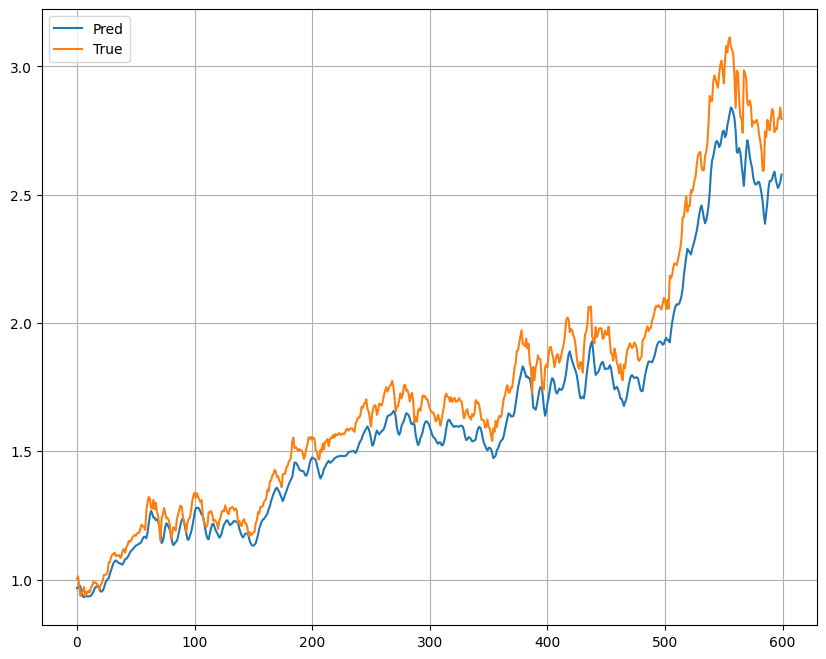

In [243]:
rnn_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y =y.float()
        yhat = rnn_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())
        
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(10, 8))
plt.plot(preds[:600], label='Pred')
plt.plot(trues[:600], label='True')
plt.legend()
plt.grid(True)
plt.show()

In [245]:
# 스케일링 데이터를 다시 원본의 데이터셋으로 변경
# inverse_transform() : 스케일링 데이터를 원본으로 변경
preds_origin = scaler.inverse_transform(preds.reshape(-1, 1)).squeeze()
trues_origin = scaler.inverse_transform(trues.reshape(-1, 1)).squeeze()

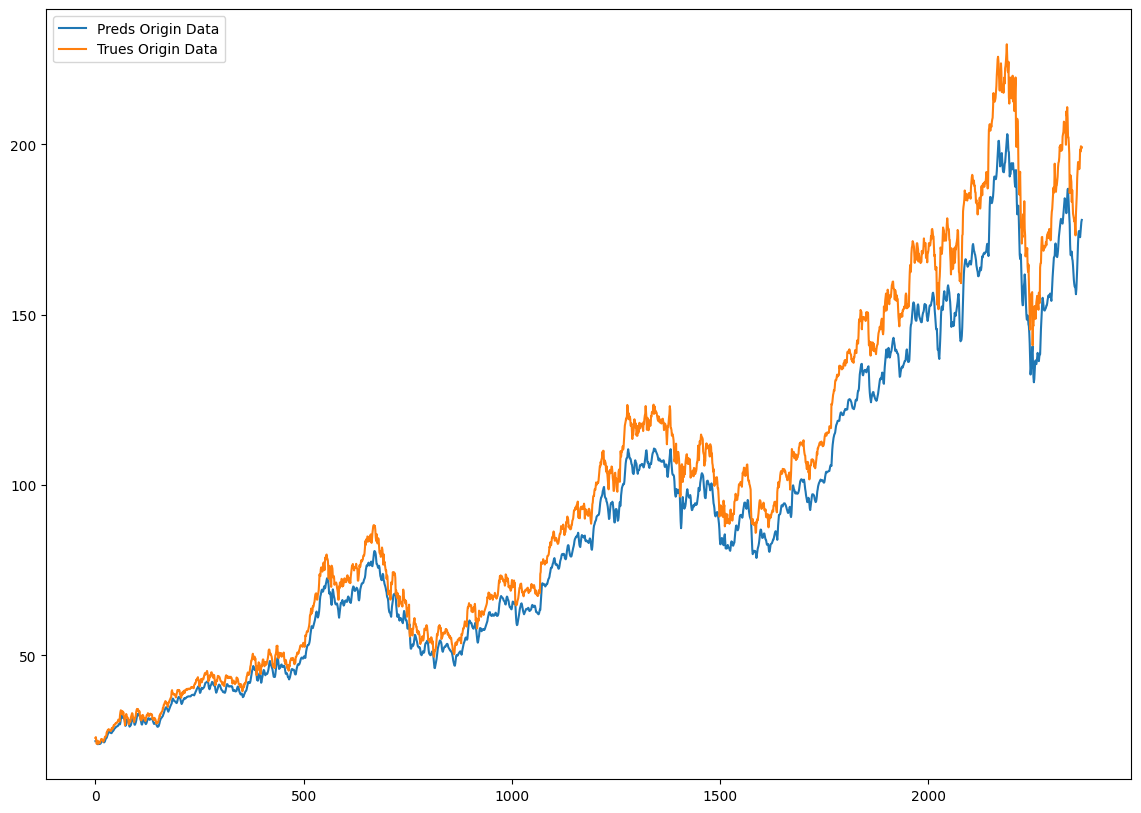

In [246]:
plt.figure(figsize=(14, 10))
plt.plot(preds_origin, label='Preds Origin Data')
plt.plot(trues_origin, label='Trues Origin Data')

plt.legend()

plt.show()

------------------------------

In [277]:
# 시계열 분석
# 2개의 피쳐(종가, 거래량) -> 타깃(종가) 예측

df = pd.read_csv("../csv/AAPL.csv")

In [278]:
# 특정 컬럼을 선택
df = df[['Date', 'Adj Close', 'Volume']]
df.dropna(axis=0, inplace=True)

In [279]:
# 피쳐 데이터 (독립변수)
X_all = df[['Adj Close', 'Volume']].astype('float').values
# 타깃 데이터
Y_all = df[['Adj Close']].astype('float').values

In [280]:
# 데이터 분할 -> 4개의 데이터가 실행 -> 8:2
split_idx = int(len(df) * 0.8)

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
Y_train, Y_test = Y_all[:split_idx], Y_all[split_idx:]

In [281]:
# 스케일러로 스케일링 -> (마지막에 예측 종가와 실제 종가의 데이터의 원본으로의 역변환을 위함)
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc = x_scaler.transform(X_test)

Y_train_sc = y_scaler.fit_transform(Y_train)
Y_test_sc = y_scaler.transform(Y_test)

In [ ]:
# DataLoader에서 구간 데이터를 나눠주기 위한 DataSet 구성
class WindowDataset(Dataset):
    def __init__(self, _x, _y, _window):
        # _x : 독립
        # _y : 종속
        # _window : 구간
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window
    # DataLoader에서 사용되는 특수 메서드 정의 : __len__(), getitem__()
    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        # 입력 데이터 (문제)
        x_window  = self.x[idx : idx + self.window]
        # 타깃 데이터 (정답)
        y_next = self.y[idx + self.window]
        # tersor 데이터로 변환 (self.x, self.y를 array형태로 받는다는 가정)
        # tensor() -> 텐서형으로 데이터를 변환 (깊은 복사 -> 데이터를 각각의 다른 위치에 저장)
        # from_numpy() -> 텐서형으로 데이터를 변환(얕은 복사 -> 데이터의 위치는 같고 라벨을 추가)
        x_tensor = torch.from_numpy(x_window)
        y_tensor = torch.from_numpy(y_next)
        return x_tensor, y_tensor

In [315]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, foward()함수
    
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size= input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        #self.head = nn.Linear(hidden_size, 1)      # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size을 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Linear(out_features, out_features * 2),
            nn.ReLU(),
            nn.Linear(out_features * 2, 1)
            
        )
        
    def forward(self, x):
        # out -> 모든 시점에서는 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값
        # -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

In [316]:
# 구간별 데이터셋을 구정
train_ds = WindowDataset(X_train_sc, Y_train_sc, 60)
test_ds = WindowDataset(X_test_sc, Y_test_sc, 60)

train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)

In [317]:
rnn_model = RNNReg(
    input_size=2, hidden_size=64
)

# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
# 함수 호출 시 동시에 실행이 되는 데코레이터 생성
@torch.no_grad()
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    # with torch.no_grad():
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        # 총 손실
        total_loss += loss.item() * y.size(0)
        # loss.itme() : 손실의 평균
        # size(0) : 개수
        total_n += y.size(0)
    return total_loss / max(total_n, 1)


In [318]:
for epoch in range(20):
    rnn_model.train()
    running=0.0
    n_seen = 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        
        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        running += loss.item() * y.size(0)
        n_seen += y.size(0)
        
    train_mse = running / max(n_seen, 1)
    test_mse = evaliate_mse(test_dl)
    print(f"epoch : {epoch + 1}, train_mse : {round(train_mse, 3)}, test_mse : {round(test_mse, 5)}")

epoch : 1, train_mse : 0.092, test_mse : 42.66737
epoch : 2, train_mse : 0.001, test_mse : 40.01632
epoch : 3, train_mse : 0.001, test_mse : 38.51907
epoch : 4, train_mse : 0.001, test_mse : 36.47827
epoch : 5, train_mse : 0.001, test_mse : 35.01048
epoch : 6, train_mse : 0.002, test_mse : 33.78722
epoch : 7, train_mse : 0.001, test_mse : 32.99979
epoch : 8, train_mse : 0.001, test_mse : 31.78877
epoch : 9, train_mse : 0.001, test_mse : 30.97811
epoch : 10, train_mse : 0.001, test_mse : 30.20386
epoch : 11, train_mse : 0.001, test_mse : 29.57711
epoch : 12, train_mse : 0.001, test_mse : 29.01356
epoch : 13, train_mse : 0.001, test_mse : 27.74501
epoch : 14, train_mse : 0.001, test_mse : 26.81512
epoch : 15, train_mse : 0.001, test_mse : 25.95436
epoch : 16, train_mse : 0.001, test_mse : 25.64288
epoch : 17, train_mse : 0.001, test_mse : 25.19459
epoch : 18, train_mse : 0.001, test_mse : 24.62477
epoch : 19, train_mse : 0.001, test_mse : 24.84826
epoch : 20, train_mse : 0.001, test_mse 

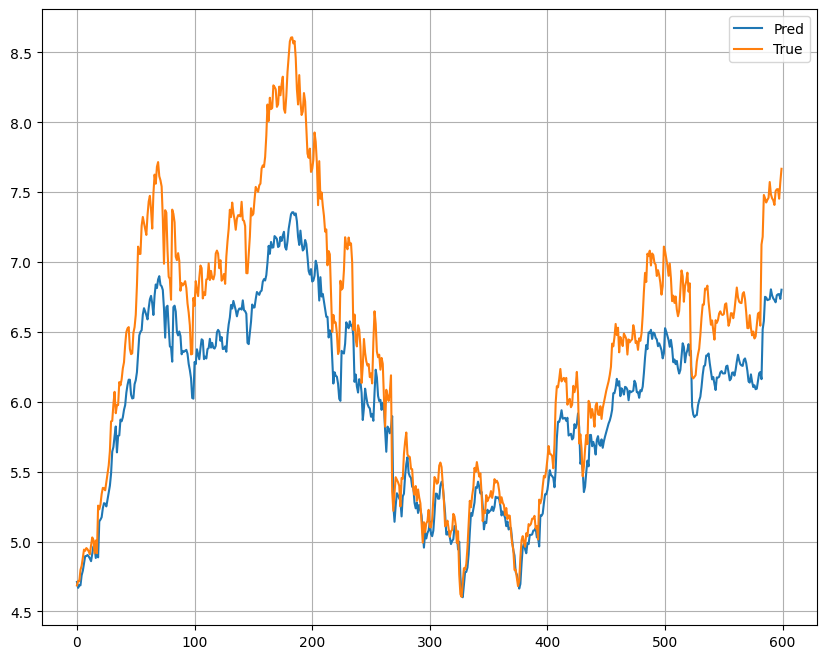

In [319]:
rnn_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y =y.float()
        yhat = rnn_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())
        
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(10, 8))
plt.plot(preds[:600], label='Pred')
plt.plot(trues[:600], label='True')
plt.legend()
plt.grid(True)
plt.show()